# In-class Activity #12 (August 11, 2026)

In [1]:
library(tidyverse)
library(moderndive)
library(car)
library(glmnet)

── Attaching core tidyverse packages ─────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ───────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 5.0



In [2]:
wage_data <- read.table("data/wage.txt", header=TRUE)
head(wage_data)

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,8,0,1,21,0,5.10,35,2,6,1,1
2,9,0,1,42,0,4.95,57,3,6,1,1
3,12,0,0,1,0,6.67,19,3,6,1,0
4,12,0,0,4,0,4.00,22,3,6,0,0
5,12,0,0,17,0,7.50,35,3,6,0,1
6,13,0,0,9,1,13.07,28,3,6,0,0


### Part A

In [3]:
wage_data_with_factors <- wage_data %>%
    mutate(across(c(race, occupation, sector), as.factor))
head(wage_data_with_factors)

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<fct>,<fct>,<fct>,<int>
1,8,0,1,21,0,5.10,35,2,6,1,1
2,9,0,1,42,0,4.95,57,3,6,1,1
3,12,0,0,1,0,6.67,19,3,6,1,0
4,12,0,0,4,0,4.00,22,3,6,0,0
5,12,0,0,17,0,7.50,35,3,6,0,1
6,13,0,0,9,1,13.07,28,3,6,0,0


In [4]:
x <- model.matrix(wage ~ ., data = wage_data_with_factors)[, -1]
y <- as.matrix(wage_data$wage)

head(x)
head(y)

,education,south,sex,experience,union,age,race2,race3,occupation2,occupation3,occupation4,occupation5,occupation6,sector1,sector2,marr
1,8,0,1,21,0,35,1,0,0,0,0,0,1,1,0,1
2,9,0,1,42,0,57,0,1,0,0,0,0,1,1,0,1
3,12,0,0,1,0,19,0,1,0,0,0,0,1,1,0,0
4,12,0,0,4,0,22,0,1,0,0,0,0,1,0,0,0
5,12,0,0,17,0,35,0,1,0,0,0,0,1,0,0,1
6,13,0,0,9,1,28,0,1,0,0,0,0,1,0,0,0


5.10
4.95
6.67
4.00
7.50
13.07


In [5]:
cvfit <- cv.glmnet(x, y, alpha=1)
cvfit


Call:  cv.glmnet(x = x, y = y, alpha = 1) 

Measure: Mean-Squared Error 

    Lambda Index Measure    SE Nonzero
min 0.0225    49   18.82 3.450      15
1se 0.7734    11   22.24 3.472       4

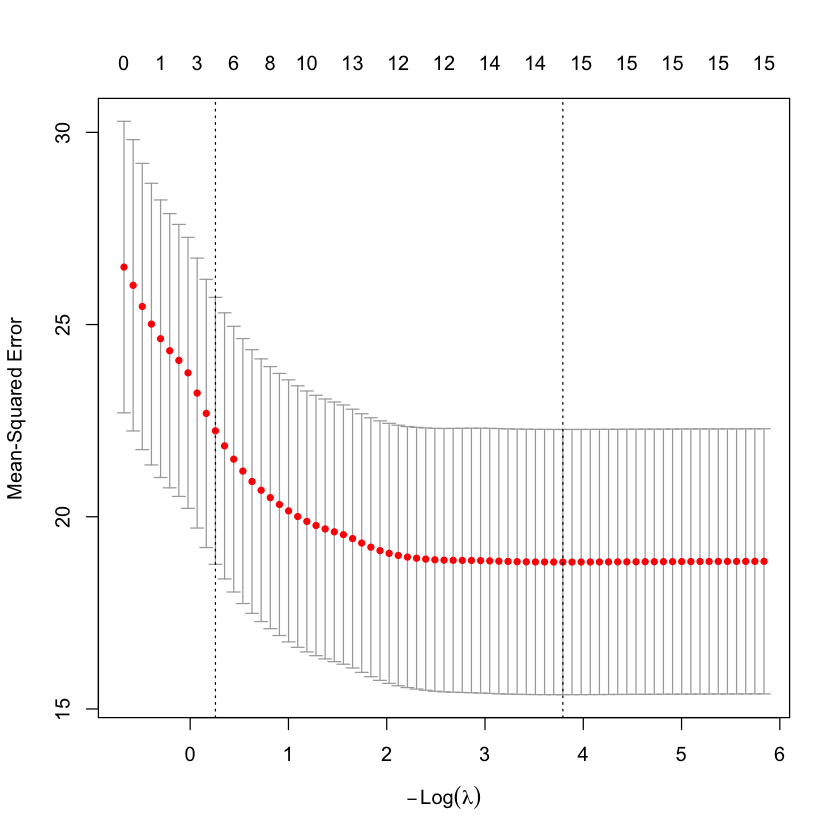

In [6]:
plot(cvfit)

In [7]:
coef(cvfit, s = "lambda.min")

17 x 1 sparse Matrix of class "dgCMatrix"
              lambda.min
(Intercept)  0.546080234
education    0.568562023
south       -0.546590566
sex         -1.904707896
experience   .          
union        1.501791251
age          0.086358168
race2        0.003503712
race3        0.709482994
occupation2 -3.571282809
occupation3 -2.828909861
occupation4 -3.525866935
occupation5 -0.844025333
occupation6 -2.748557331
sector1      0.911893404
sector2      0.276818712
marr         0.270686078

The predictors selected based on the penalty value `lambda` chosen by the cross-validation method are:
* `education`
* `south`
* `sex`
* `union`
* `age`
* `race`
* `occupation`
* `sector`
* `marr`

### Part B

In [8]:
full_model <- lm(wage ~ education + south + sex + 
                 experience + union + age + factor(race) + 
                 factor(occupation) + factor(sector) + marr, data= wage_data)
stepwise_model <- step(full_model, direction="backward")

Start:  AIC=1570.12
wage ~ education + south + sex + experience + union + age + factor(race) + 
    factor(occupation) + factor(sector) + marr

                     Df Sum of Sq     RSS    AIC
- age                 1      0.39  9481.2 1568.1
- experience          1      0.94  9481.7 1568.2
- factor(race)        2     44.55  9525.3 1568.6
- marr                1      9.79  9490.6 1568.7
- education           1     10.26  9491.0 1568.7
- factor(sector)      2     65.90  9546.7 1569.8
- south               1     32.95  9513.7 1570.0
<none>                             9480.8 1570.1
- union               1    178.95  9659.7 1578.1
- sex                 1    393.34  9874.1 1589.8
- factor(occupation)  5    641.71 10122.5 1595.1

Step:  AIC=1568.14
wage ~ education + south + sex + experience + union + factor(race) + 
    factor(occupation) + factor(sector) + marr

                     Df Sum of Sq     RSS    AIC
- factor(race)        2     44.62  9525.8 1566.7
- marr                1      9.6

In [9]:
coef(stepwise_model)

(Intercept)           education               south                 sex 
         1.97951645          0.67228777         -0.68858430         -1.84526688 
         experience               union factor(occupation)2 factor(occupation)3 
         0.09369546          1.51737705         -3.97544338         -3.34711815 
factor(occupation)4 factor(occupation)5 factor(occupation)6 
        -4.14818442         -1.26790875         -2.79902368

After using stepwise selection using backwards selection, we can see that the following variables are selected:
* `education`
* `south`
* `sex`
* `experience`
* `union`
* `occupation`

This differs from using penalty-driven cross validation to select the predictors since the stepwise method did not select `age`, `race`, `sector`, and `marr` whereas the penalty-driven cross validation method selected all of these while dropping `experience` (which the stepwise method included).

The reason for the different predictor selection comes down to different underlying mechanisms. Part A uses LASSO which shrinks the coefficients down to 0 based on the `lambda` penalty values. However, part B uses stepwise selection based on the AIC value; it starts with the full model and removes one predictor at a time until it arrives at its final selection of predictors. The LASSO method is smooth, meaning that different predictors can have different weights, however, when using stepwise selection, this is a binary process since it either selects or does not select certain predictors (i.e. there is not "in-between").